In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("adult.csv")

# Basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nFirst 5 rows:")
print(df.head())

Shape: (48842, 15)

Columns:
 Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

First 5 rows:
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male         

In [2]:
# Data types
print("\nData Types:\n", df.dtypes)

# Summary statistics (numerical)
print("\nStatistical Summary:\n", df.describe())

# Summary including categorical
print("\nFull Summary:\n", df.describe(include='all'))


Data Types:
 age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

Statistical Summary:
                 age        fnlwgt  educational-num  capital-gain  \
count  48842.000000  4.884200e+04     48842.000000  48842.000000   
mean      38.643585  1.896641e+05        10.078089   1079.067626   
std       13.710510  1.056040e+05         2.570973   7452.019058   
min       17.000000  1.228500e+04         1.000000      0.000000   
25%       28.000000  1.175505e+05         9.000000      0.000000   
50%       37.000000  1.781445e+05        10.000000      0.000000   
75%       48.000000  2.376420e+05        12.000000      0.000000   
max       90.00

In [3]:
# Check missing values
print("\nMissing Values Count:\n", df.isnull().sum())

# If dataset uses '?' as missing value
df.replace('?', np.nan, inplace=True)

print("\nMissing Values After Replacement:\n", df.isnull().sum())


Missing Values Count:
 age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

Missing Values After Replacement:
 age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


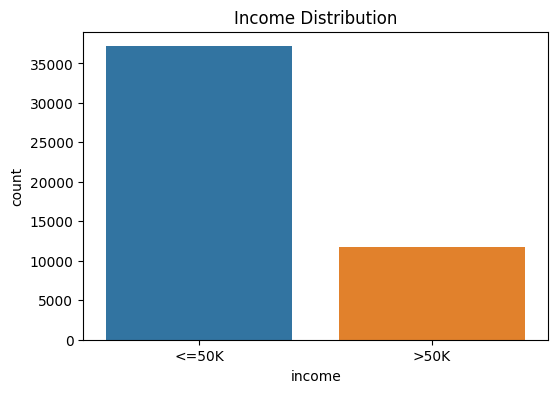

income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='income', data=df)
plt.title("Income Distribution")
plt.show()

print(df['income'].value_counts(normalize=True))

In [5]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Categorical Columns: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')


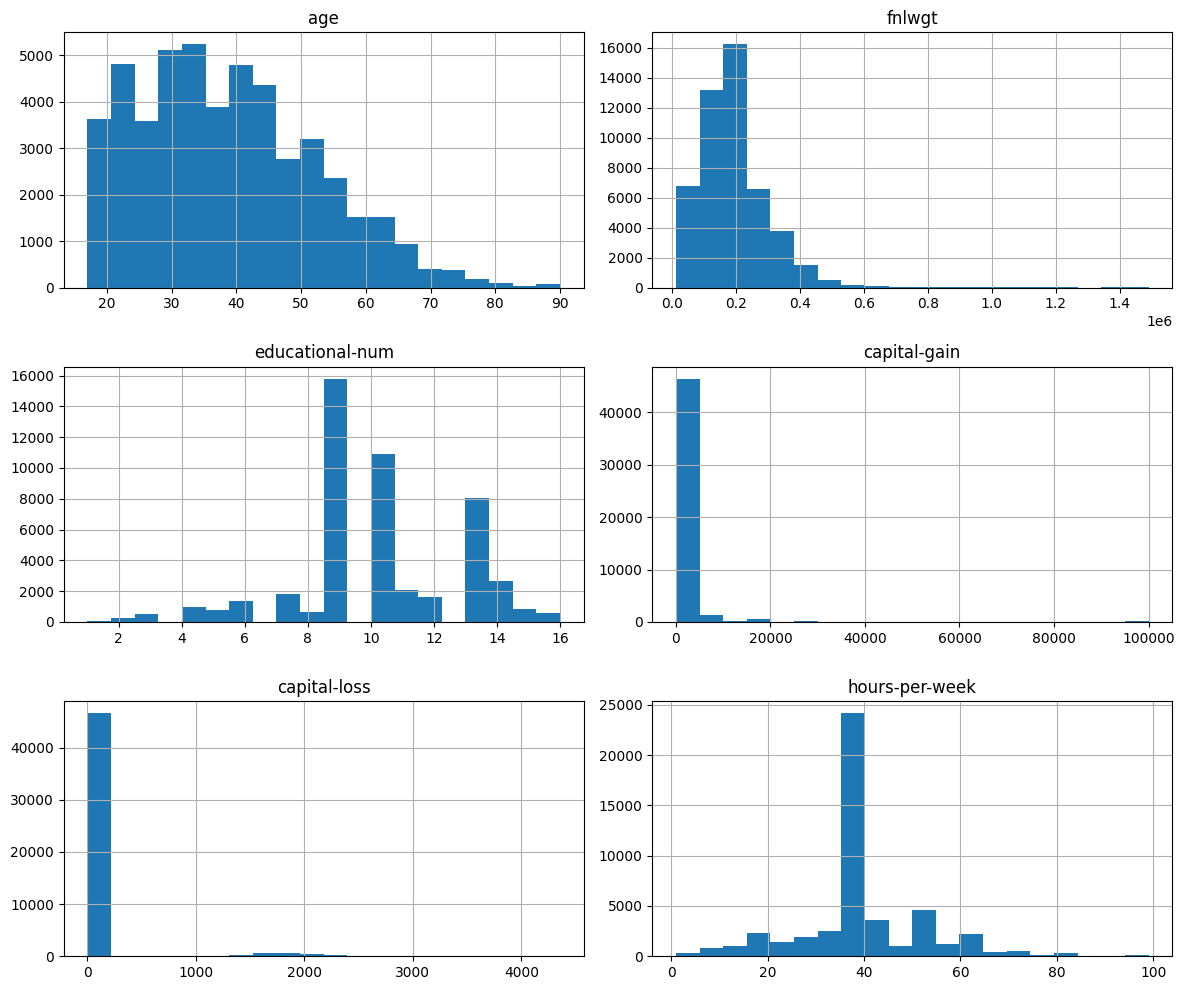

In [6]:
df[numerical_cols].hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()


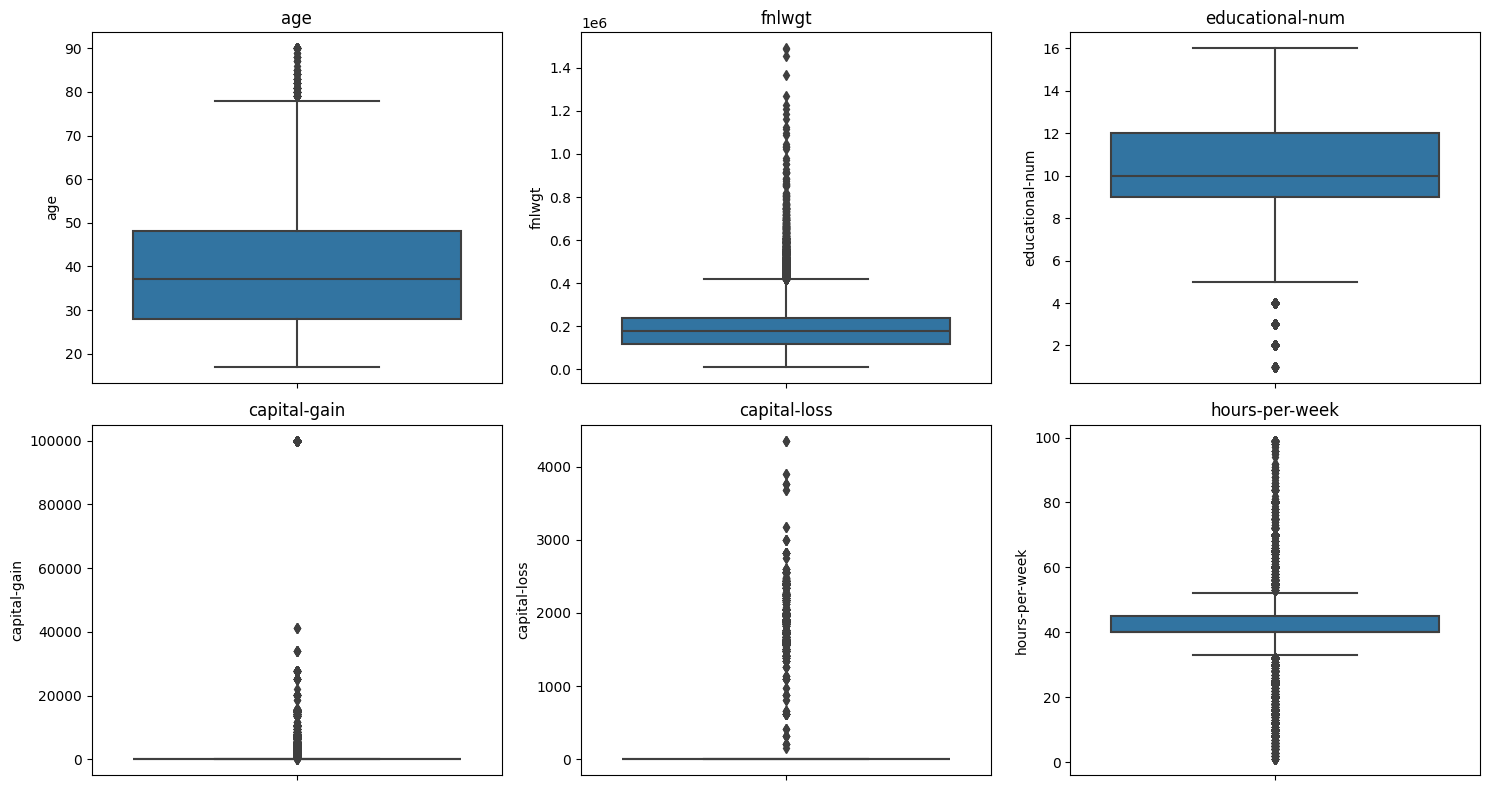

In [7]:
plt.figure(figsize=(15,8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [8]:
for col in categorical_cols:
    print(f"\n{col} Value Counts:\n")
    print(df[col].value_counts())


workclass Value Counts:

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

education Value Counts:

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

marital-status Value Counts:

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

occupation Value Counts:



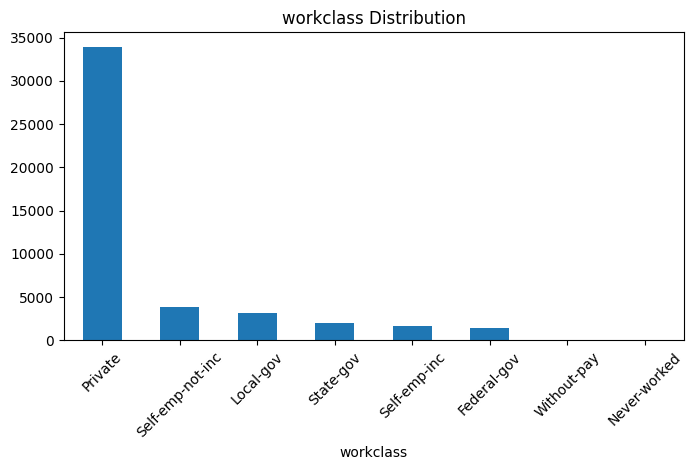

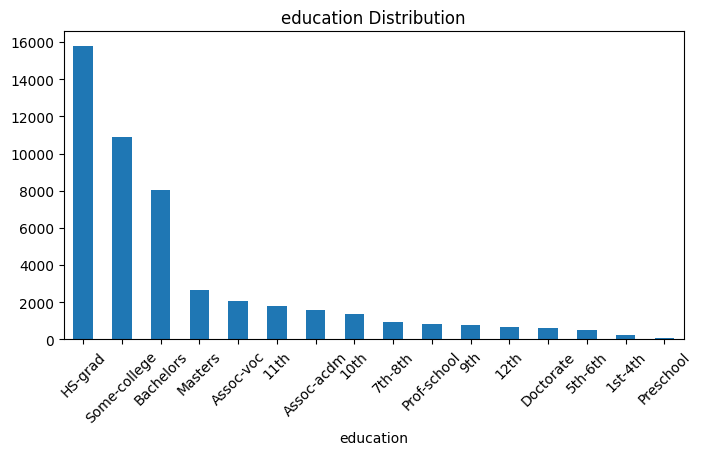

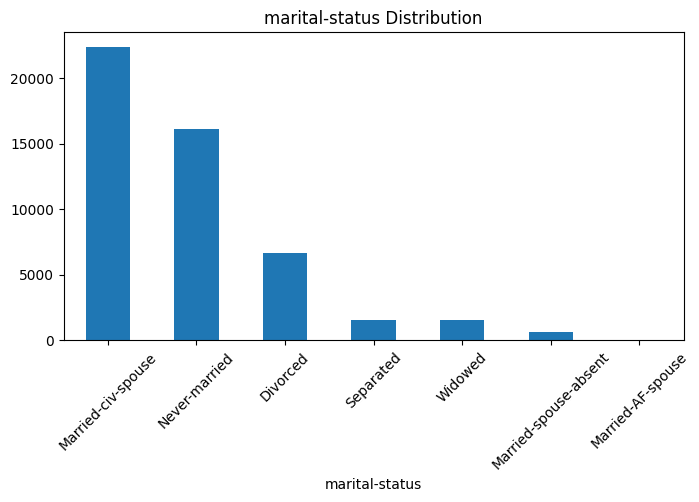

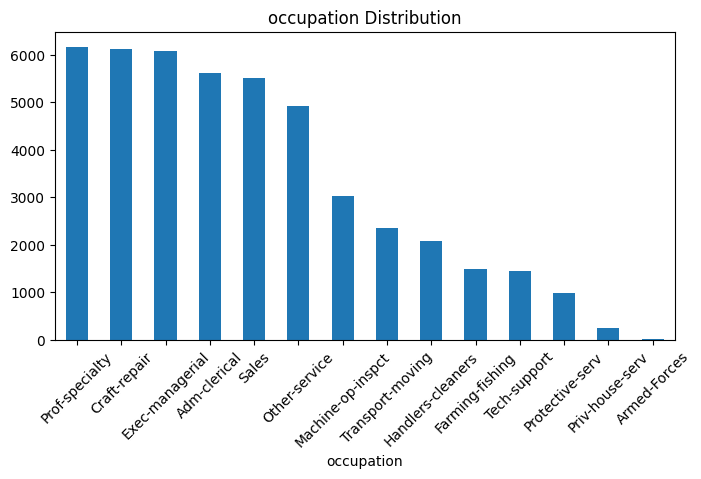

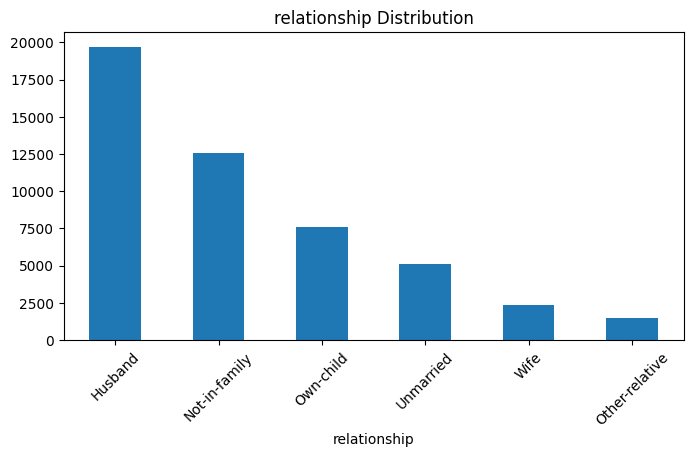

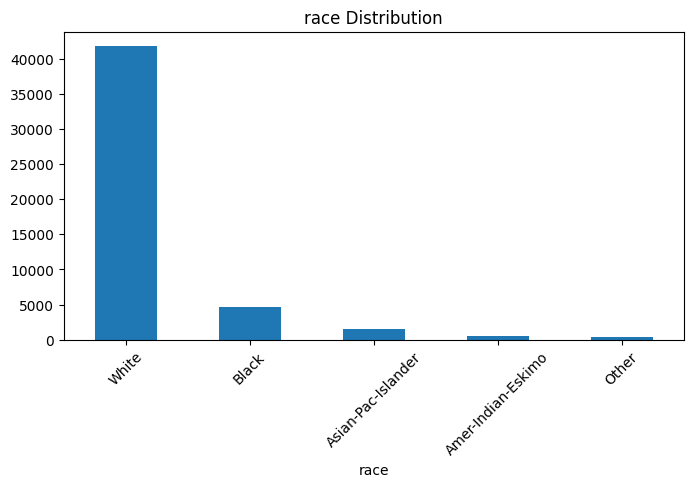

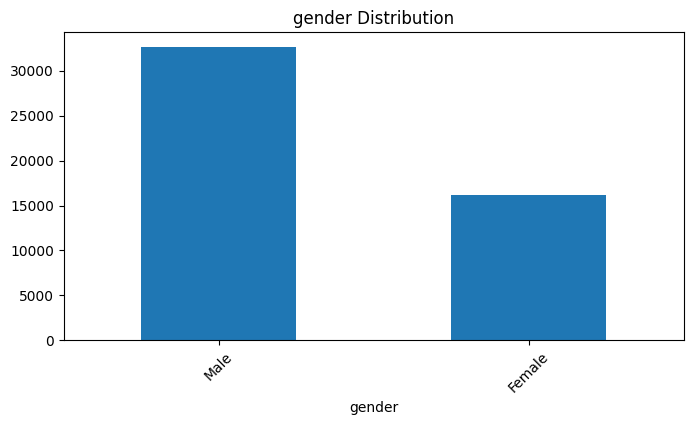

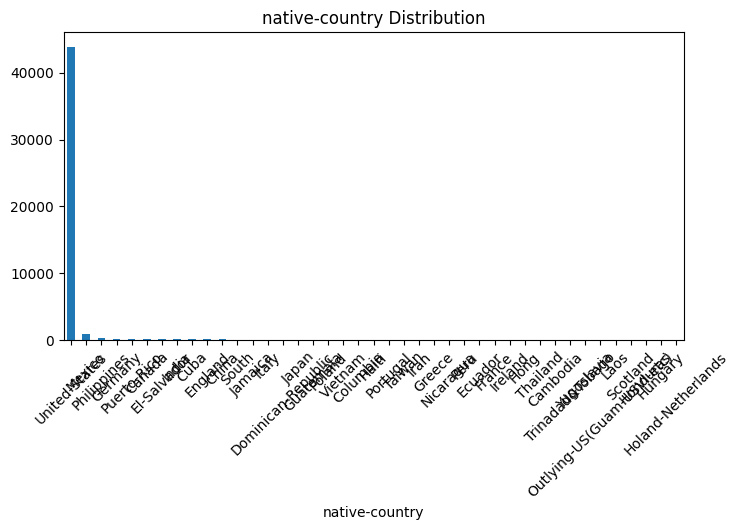

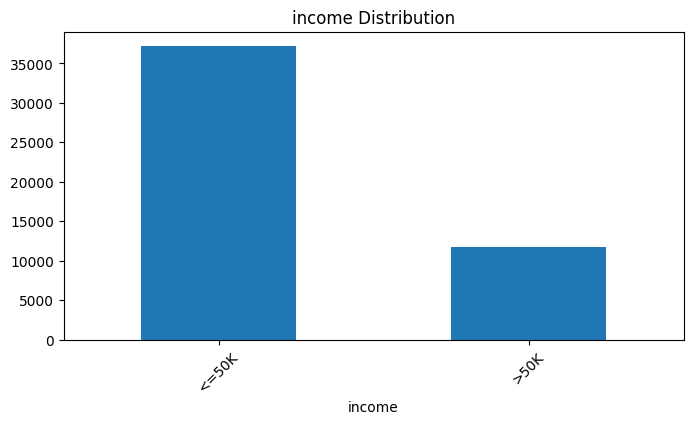

In [9]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()


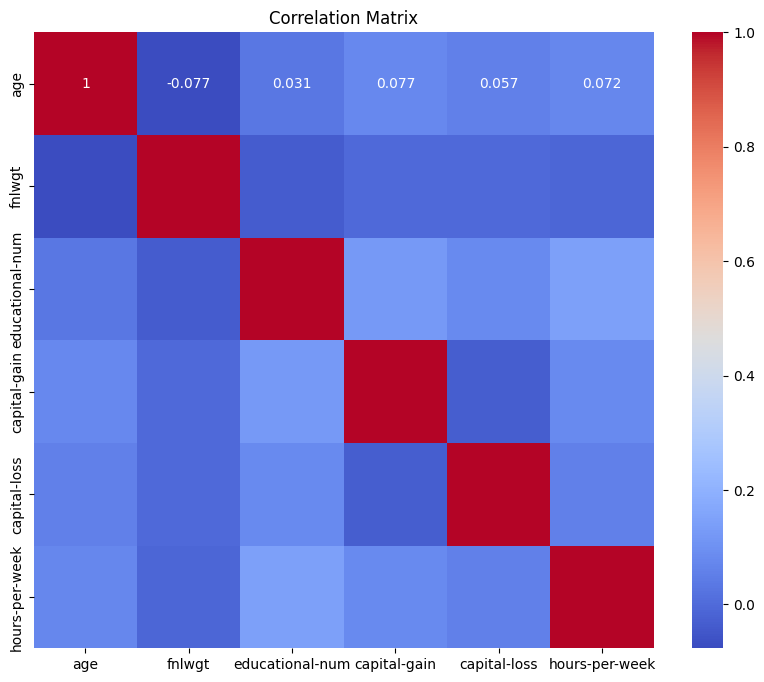

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

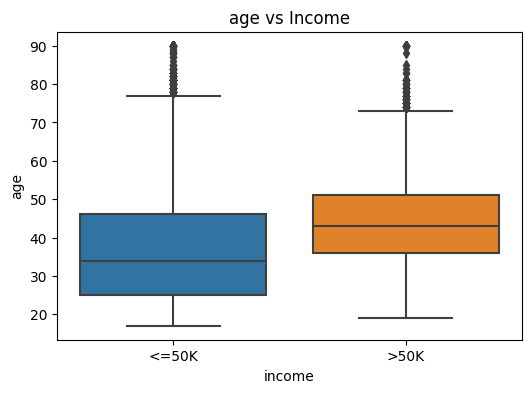

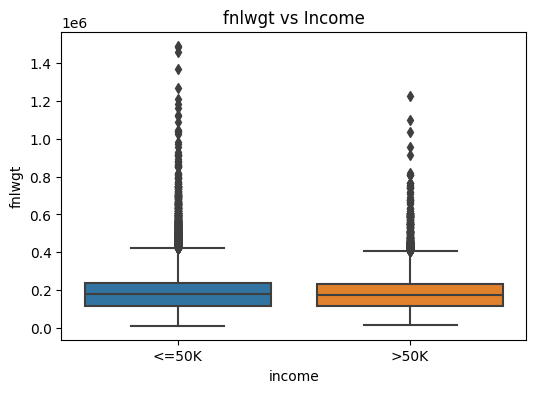

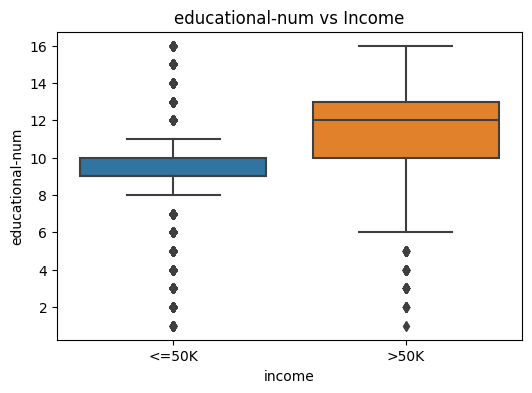

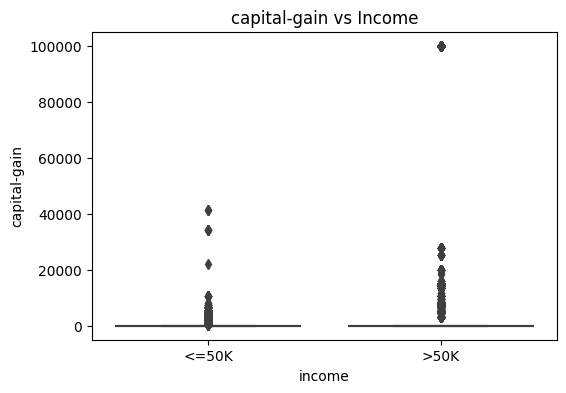

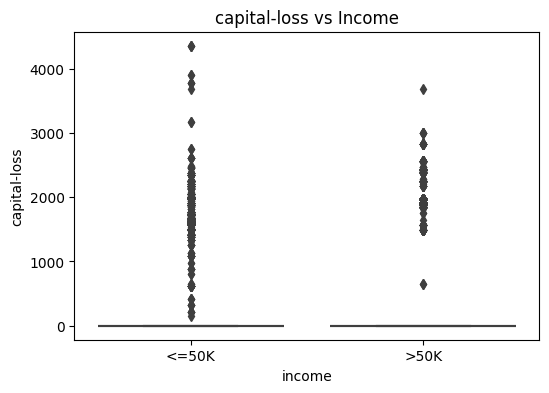

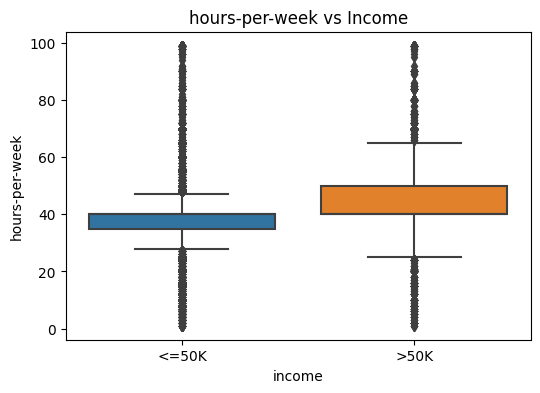

In [11]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='income', y=col, data=df)
    plt.title(f"{col} vs Income")
    plt.show()


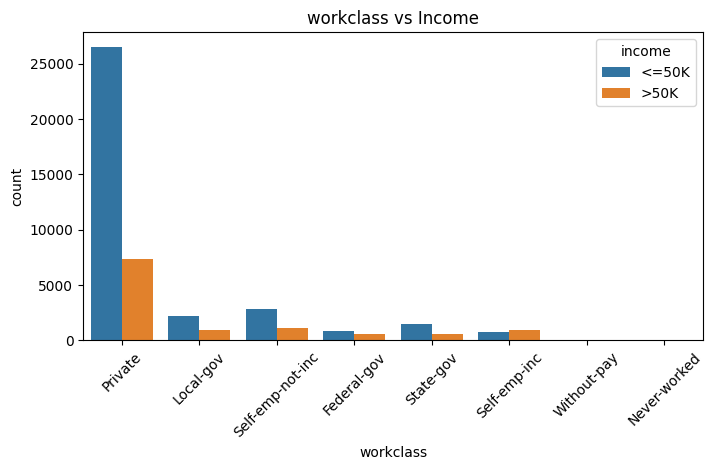

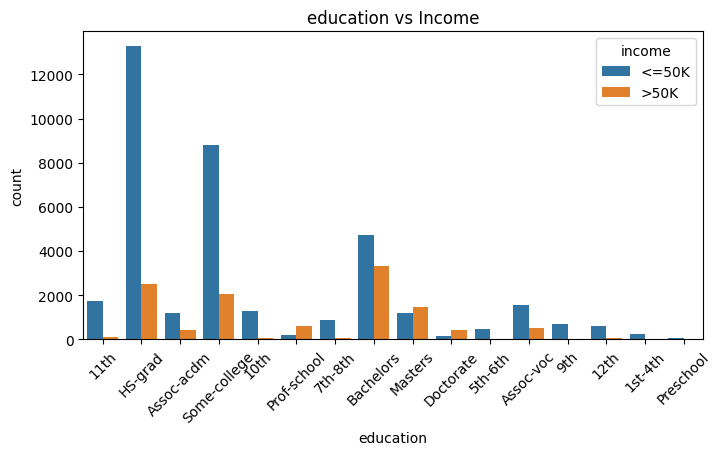

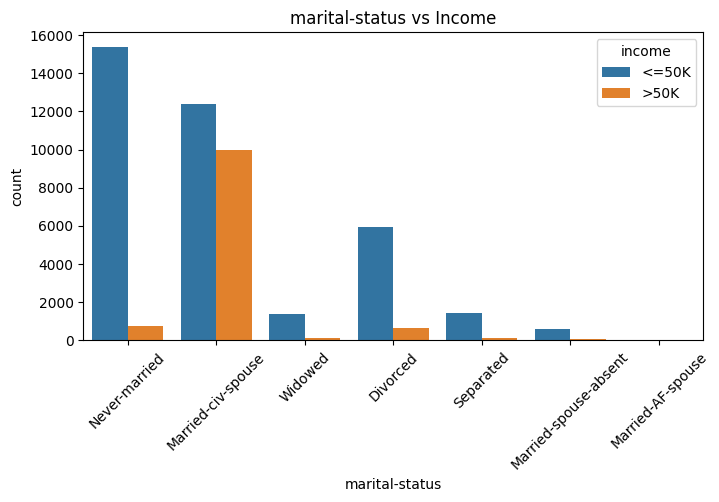

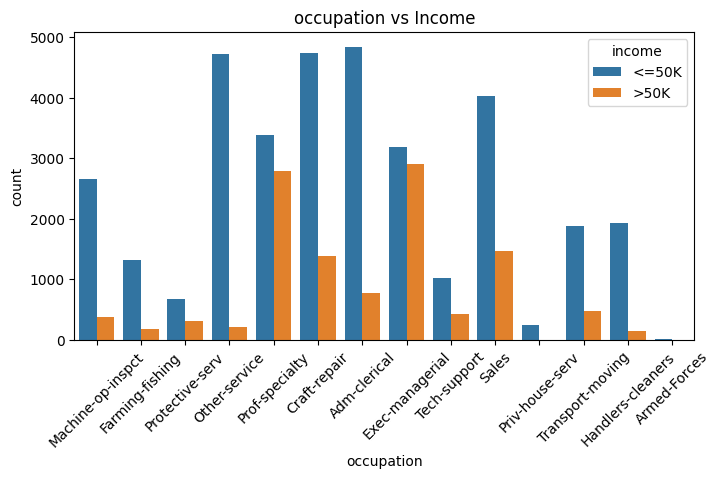

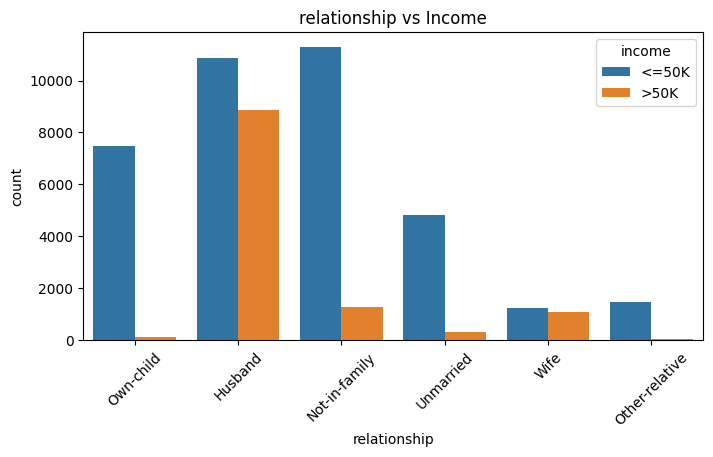

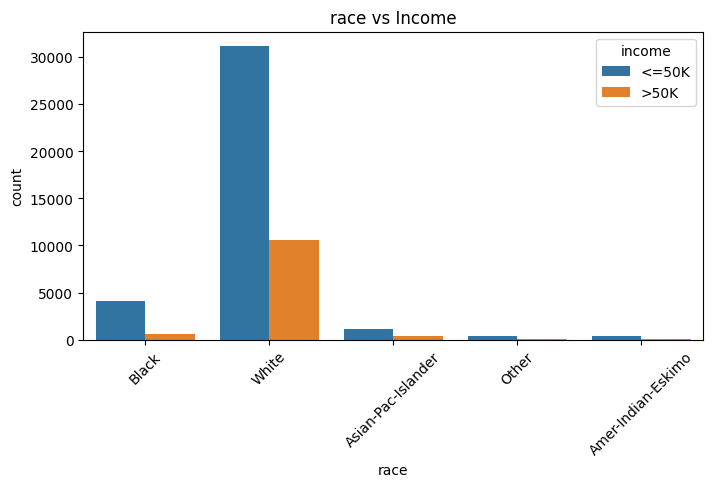

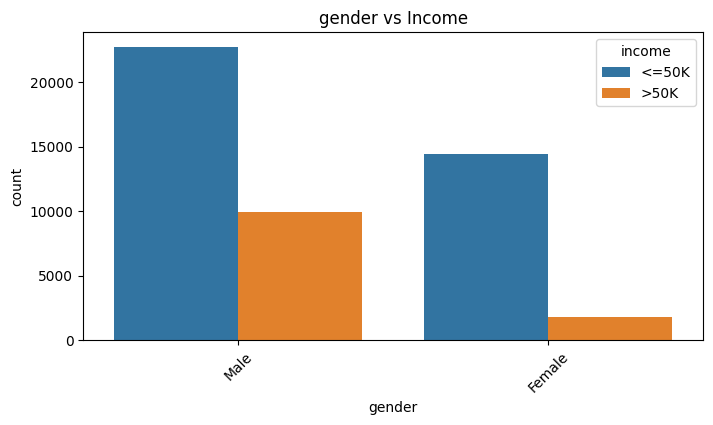

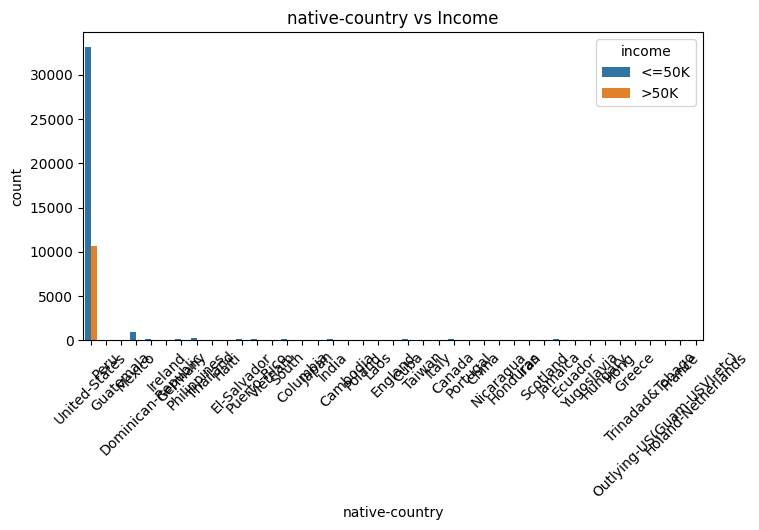

In [12]:
for col in categorical_cols:
    if col != 'income':
        plt.figure(figsize=(8,4))
        sns.countplot(x=col, hue='income', data=df)
        plt.xticks(rotation=45)
        plt.title(f"{col} vs Income")
        plt.show()

In [13]:
print("Skewness:\n", df[numerical_cols].skew())

Skewness:
 age                 0.557580
fnlwgt              1.438892
educational-num    -0.316525
capital-gain       11.894659
capital-loss        4.569809
hours-per-week      0.238750
dtype: float64


C:\Users\tosha\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\tosha\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\tosha\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\tosha\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and wil

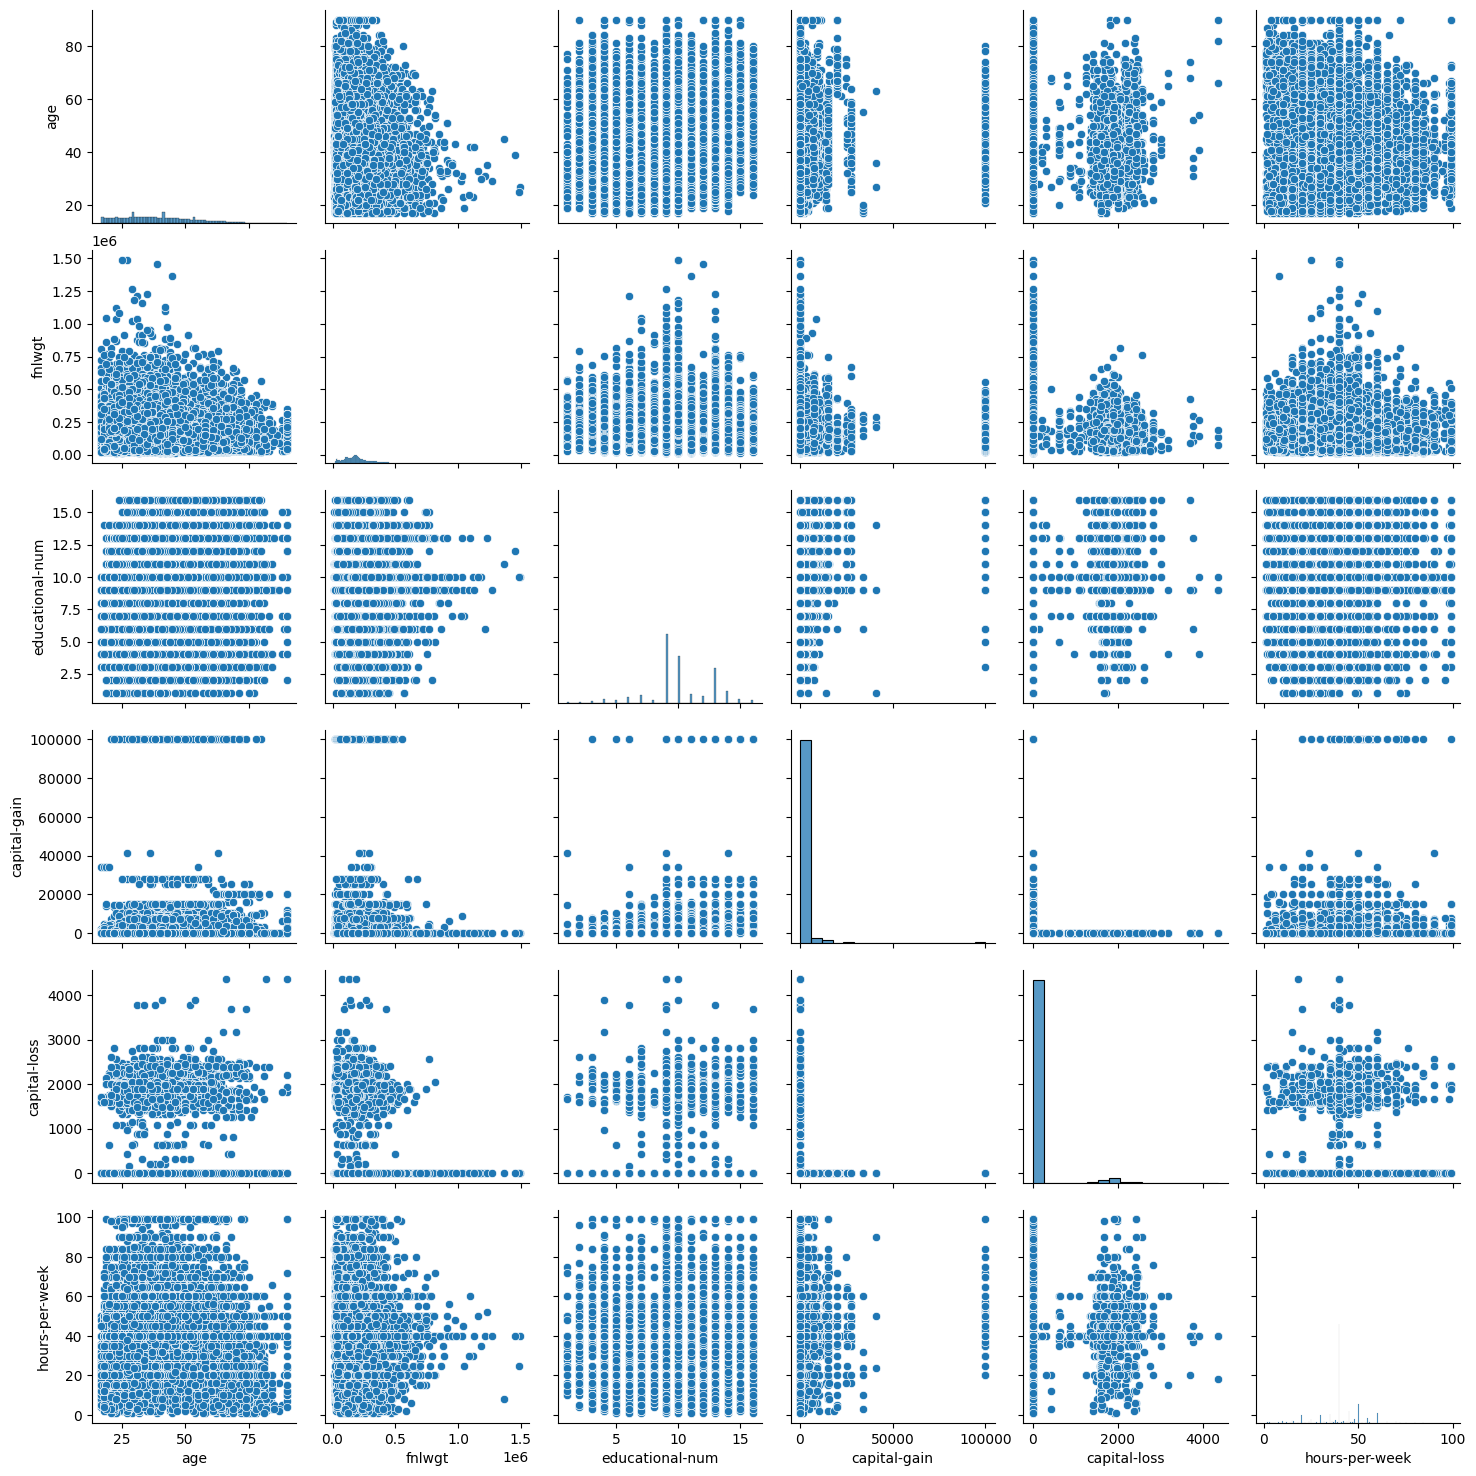

In [14]:
sns.pairplot(df[numerical_cols])
plt.show()

In [15]:
income_counts = df['income'].value_counts()
print("Class Distribution:\n", income_counts)

imbalance_ratio = income_counts.min() / income_counts.max()
print("Imbalance Ratio:", imbalance_ratio)

Class Distribution:
 income
<=50K    37155
>50K     11687
Name: count, dtype: int64
Imbalance Ratio: 0.3145471672722379


  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
  Using cached numba-0.62.1-cp311-cp311-win_amd64.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   -------------------------- ------------- 1.8/2.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 8.0 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.8/38.1 MB 9.1 MB/s eta 0:00:04
   ---- ----------------------------------- 3.9/38.1 MB 9.4 MB/s eta 0:00:04
   ------ --------------------------------- 6.0/38.1 MB 9.5 MB/s eta 0:00:04
   -------- ------------------------------- 7.9/38.1 MB 9.2 MB/s eta 0:00:04
   ---------- ----------------------------- 9.7/38.1 MB 9.2 MB/s eta 0:00:04
   ----------- ---------------------------- 11.3/38.1 MB 9.2 MB/s eta 0:00:03
   ------------- -------------------------- 13.1/38.1 MB 9.0 MB/s eta 0:00:03
   --------------- --------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.41 requires requests_mock, which is not installed.
embedchain 0.1.125 requires chromadb<0.6.0,>=0.5.10, but you have chromadb 1.0.7 which is incompatible.
jina 3.25.1 requires grpcio<=1.57.0,>=1.46.0, but you have grpcio 1.69.0 which is incompatible.
jina 3.25.1 requires opentelemetry-sdk<1.20.0,>=1.14.0, but you have opentelemetry-sdk 1.24.0 which is incompatible.
jina 3.25.1 requires pydantic<2.0.0, but you have pydantic 2.10.4 which is incompatible.
jina 3.25.1 requires uvicorn[standard]<=0.23.1, but you have uvicorn 0.23.2 which is incompatible.
langchain-chroma 0.2.3 requires chromadb!=0.5.10,!=0.5.11,!=0.5.12,!=0.5.4,!=0.5.5,!=0.5.7,!=0.5.9,<0.7.0,>=0.4.0, but you have chromadb 1.0.7 which is incompatible.
langchain-google-genai 2.1.4 requires google-ai-generativelanguage<0.7.0,>=0.6.18, b

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:01<00:00, 10.28it/s]
C:\Users\tosha\AppData\Roaming\Python\Python311\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)
c:\Users\tosha\anaconda3\Lib\site-packages\ydata_profiling\model\missing.py:132: UserWarning: There was an attempt to generate the Heatmap missing values diagrams, but this failed.
        To hide this warning, disable the calculation
        (using `df.profile_report(missing_diagrams={"Heatmap": False}`)
        If this is problematic for your use case, please report this as an issue:
        https://github.com/ydataai/ydata-profiling/issues
        (include the error message: 'could not convert string to float: '--'')
  warnings.warn(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

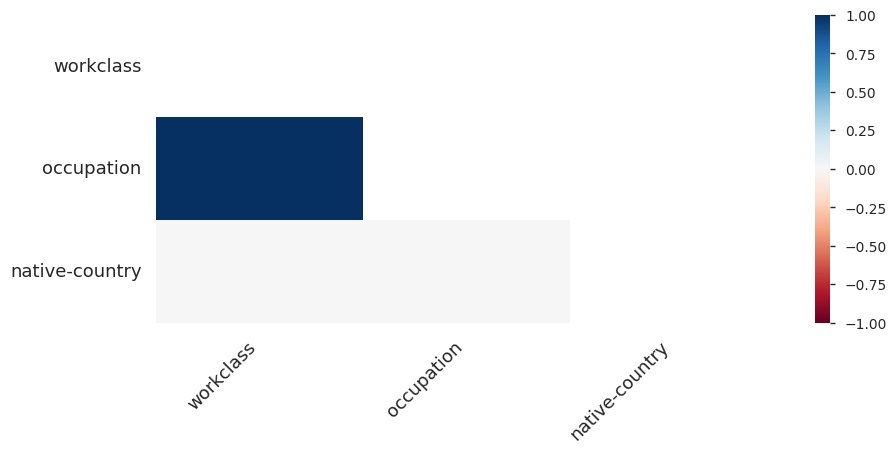

In [16]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)
profile.to_file("adult_eda_report.html")

In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier


# -------------------------
# 1️⃣ Load Dataset
# -------------------------
df = pd.read_csv("adult.csv")

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop missing values
df.dropna(inplace=True)

# Strip whitespace (important in Adult dataset)
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# -------------------------
# 2️⃣ Separate Features & Target
# -------------------------
X = df.drop("income", axis=1)
y = df["income"]

# Convert target to binary (optional but clean)
y = y.map({">50K": 1, "<=50K": 0})

# -------------------------
# 3️⃣ Identify Column Types
# -------------------------
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# -------------------------
# 4️⃣ Preprocessing Pipeline
# -------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# -------------------------
# 5️⃣ Create Model Pipeline
# -------------------------
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

# -------------------------
# 6️⃣ Train-Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# 7️⃣ Train Model
# -------------------------
model.fit(X_train, y_train)

# -------------------------
# 8️⃣ Predictions
# -------------------------
y_pred = model.predict(X_test)

# -------------------------
# 9️⃣ Evaluation
# -------------------------
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8664455500276396

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      6803
           1       0.77      0.66      0.71      2242

    accuracy                           0.87      9045
   macro avg       0.83      0.80      0.81      9045
weighted avg       0.86      0.87      0.86      9045


Confusion Matrix:

[[6366  437]
 [ 771 1471]]


In [18]:
# Get preprocessor
preprocessor = model.named_steps["preprocessing"]

# Get feature names after transformation
ohe = preprocessor.named_transformers_["cat"]
categorical_feature_names = ohe.get_feature_names_out(categorical_cols)

all_feature_names = list(numerical_cols) + list(categorical_feature_names)

In [19]:
xgb_model = model.named_steps["classifier"]

importances = xgb_model.feature_importances_

In [20]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
})

importance_df = importance_df.sort_values(by="importance", ascending=False)

importance_df

,feature,importance
31,marital-status_Married-civ-spouse,0.462812
2,educational-num,0.055984
3,capital-gain,0.041545
43,occupation_Other-service,0.029901
53,relationship_Own-child,0.028056
...,...,...
77,native-country_Holand-Netherlands,0.000000
78,native-country_Honduras,0.000000
79,native-country_Hong,0.000000
80,native-country_Hungary,0.000000


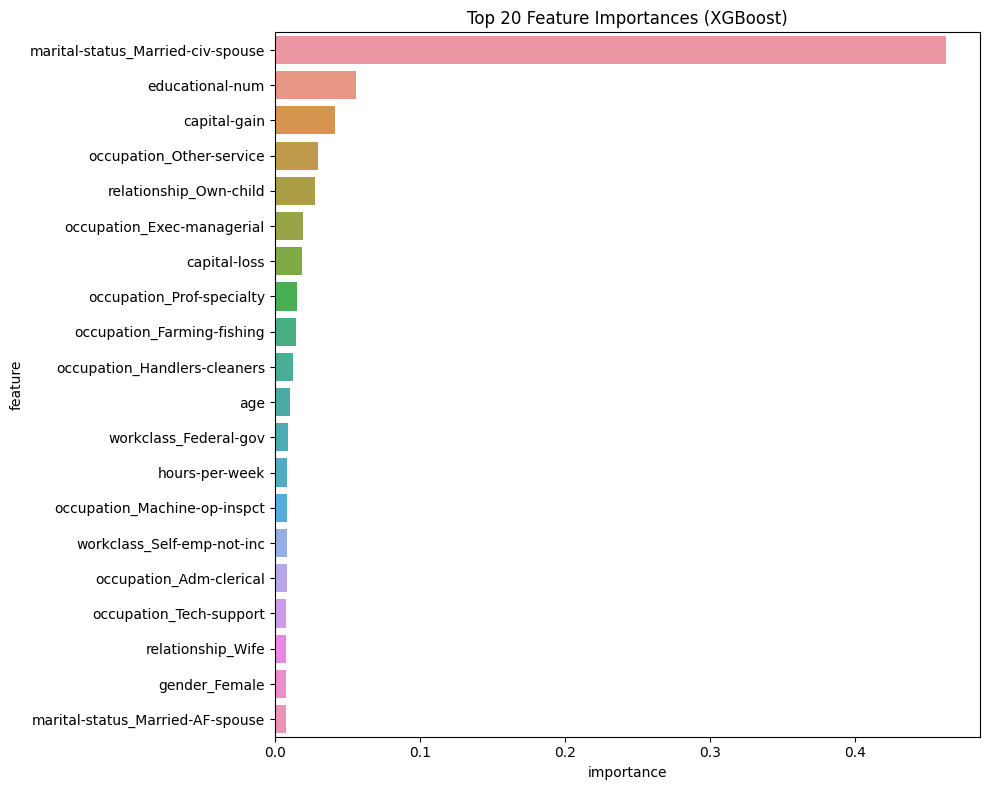

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.barplot(
    x="importance",
    y="feature",
    data=importance_df.head(20)
)
plt.title("Top 20 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()